# ANN-UTADIS - Car Preference Learning

**Aleksander Hański 160315 and Michał Żurawski 160252**

We train an **ANN-UTADIS** model: an additive utility model in which every
criterion's marginal value function `u_j(x_j)` is a small monotone neural
network, the total utility is `U(x) = Σ u_j(x_j)`, and the class probability
is `sigmoid((U − τ) / s)`.  Monotonicity is enforced by squaring all weights
in the per-criterion MLPs - this makes each `u_j` provably monotone in the
(normalised, cost-inverted) input, so the model is fully interpretable:
the user's preferences are literally the learned marginal value functions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import shap

from common_cars import (
    FEATURE_NAMES, CRITERION_DIRECTION, CRITERION_UNIT,
    load_data, report_metrics, select_three_alternatives, get_name,
    find_min_flip_sampling,
    permutation_feature_importance, plot_permutation_importance,
    plot_pdp_ice_grid,
)

torch.manual_seed(0)
np.random.seed(0)

## 1. Load data

In [2]:
df_raw, df, X, y, X_train, X_test, y_train, y_test, FEATURE_RANGES = load_data()
print(df.shape)
print("Feature ranges:")
for f, (lo, hi) in FEATURE_RANGES.items():
    print(f"  {f}: [{lo}, {hi}]")

(177, 8)
Feature ranges:
  HorsePower: [85.0, 670.0]
  Cars Prices: [15000.0, 105000.0]
  Seats: [7.0, 12.0]
  Total Speed: [125.0, 250.0]


## 2. Normalise features to [0, 1] and invert the cost criterion

UTADIS marginal value functions are defined on normalised scales.  We also
invert `Cars Prices` so that higher normalised value = better on *every*
criterion.  The per-criterion MLPs can then be constrained to be monotone
**increasing** in their (normalised, inverted-if-cost) input, which is what
squaring the weights gives us for free.

In [3]:
def preprocess(X_raw: pd.DataFrame) -> np.ndarray:
    Xp = X_raw[FEATURE_NAMES].astype(float).copy()
    for f in FEATURE_NAMES:
        lo, hi = FEATURE_RANGES[f]
        Xp[f] = (Xp[f] - lo) / (hi - lo)
        if CRITERION_DIRECTION[f] == -1:
            Xp[f] = 1.0 - Xp[f]
    return Xp.values.astype(np.float32)


X_train_n = preprocess(X_train)
X_test_n  = preprocess(X_test)
X_all_n   = preprocess(X)

## 3. ANN-UTADIS architecture

* One tiny monotone MLP per criterion (`1 -> 8 -> 8 -> 1`).
* Positive weights via `W_eff = W ** 2` and `sigmoid` activations - both
  increasing, so the composition is monotone increasing.
* Global threshold `τ` and scale `s = exp(log_s)` are learnable.
* `P(class = 1) = sigmoid((U − τ) / s)`.

In [4]:
class MonotoneMLP(nn.Module):
    def __init__(self, hidden: int = 8):
        super().__init__()
        self.W1 = nn.Parameter(torch.randn(1, hidden) * 0.3)
        self.b1 = nn.Parameter(torch.zeros(hidden))
        self.W2 = nn.Parameter(torch.randn(hidden, hidden) * 0.3)
        self.b2 = nn.Parameter(torch.zeros(hidden))
        self.W3 = nn.Parameter(torch.randn(hidden, 1) * 0.3)
        self.b3 = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = torch.sigmoid(x @ (self.W1 ** 2) + self.b1)
        h = torch.sigmoid(h @ (self.W2 ** 2) + self.b2)
        out = h @ (self.W3 ** 2) + self.b3
        return out


class ANNUTADIS(nn.Module):
    def __init__(self, n_criteria: int = 4, hidden: int = 8):
        super().__init__()
        self.marginals = nn.ModuleList([MonotoneMLP(hidden) for _ in range(n_criteria)])
        self.tau = nn.Parameter(torch.tensor(2.0))
        self.log_s = nn.Parameter(torch.tensor(-1.0))

    def utilities(self, x: torch.Tensor) -> torch.Tensor:
        us = [m(x[:, j:j + 1]) for j, m in enumerate(self.marginals)]
        return torch.cat(us, dim=1)

    def total_utility(self, x: torch.Tensor) -> torch.Tensor:
        return self.utilities(x).sum(dim=1, keepdim=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        U = self.total_utility(x)
        s = torch.exp(self.log_s)
        return torch.sigmoid((U - self.tau) / s).squeeze(1)

## 4. Train

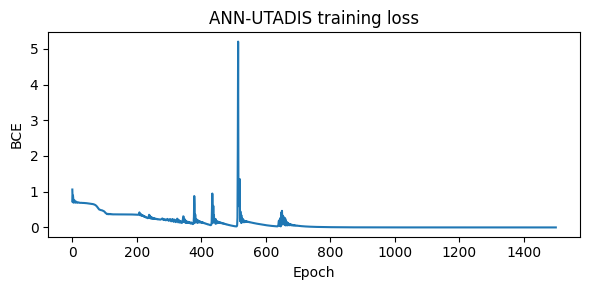

In [5]:
model = ANNUTADIS()
opt = torch.optim.Adam(model.parameters(), lr=0.05)

Xt = torch.tensor(X_train_n, dtype=torch.float32)
yt = torch.tensor(y_train.values, dtype=torch.float32)

loss_hist = []
for epoch in range(1500):
    opt.zero_grad()
    p = model(Xt)
    loss = nn.functional.binary_cross_entropy(p, yt)
    loss.backward()
    opt.step()
    loss_hist.append(float(loss.item()))

plt.figure(figsize=(6, 3))
plt.plot(loss_hist)
plt.title("ANN-UTADIS training loss")
plt.xlabel("Epoch"); plt.ylabel("BCE")
plt.tight_layout(); plt.show()

## 5. Metrics: Accuracy, F1, AUC

In [6]:
def predict_proba_df(X_df: pd.DataFrame) -> np.ndarray:
    with torch.no_grad():
        Xn = preprocess(X_df)
        return model(torch.tensor(Xn, dtype=torch.float32)).numpy()


def predict_df(X_df: pd.DataFrame) -> np.ndarray:
    return (predict_proba_df(X_df) > 0.5).astype(int)


report_metrics(predict_df, predict_proba_df, X_train, y_train, X_test, y_test)

Train | Accuracy=1.0000  F1=1.0000  AUC=1.0000
Test  | Accuracy=0.9722  F1=0.9714  AUC=0.9846


{'Train': {'Accuracy': 1.0, 'F1': 1.0, 'AUC': 1.0},
 'Test': {'Accuracy': 0.9722, 'F1': 0.9714, 'AUC': 0.9846}}

## 6. Marginal value functions - the primary ANN-UTADIS interpretation

Each plot shows `u_j(x_j)` over the **raw** criterion value.  Because cost
criteria are inverted before going into the monotone MLP, the plot against
raw price is decreasing (higher price -> lower marginal utility), exactly as
expected for a cost criterion.  The *range* of each curve measures how much
that criterion can move the overall utility - i.e., its learned importance.

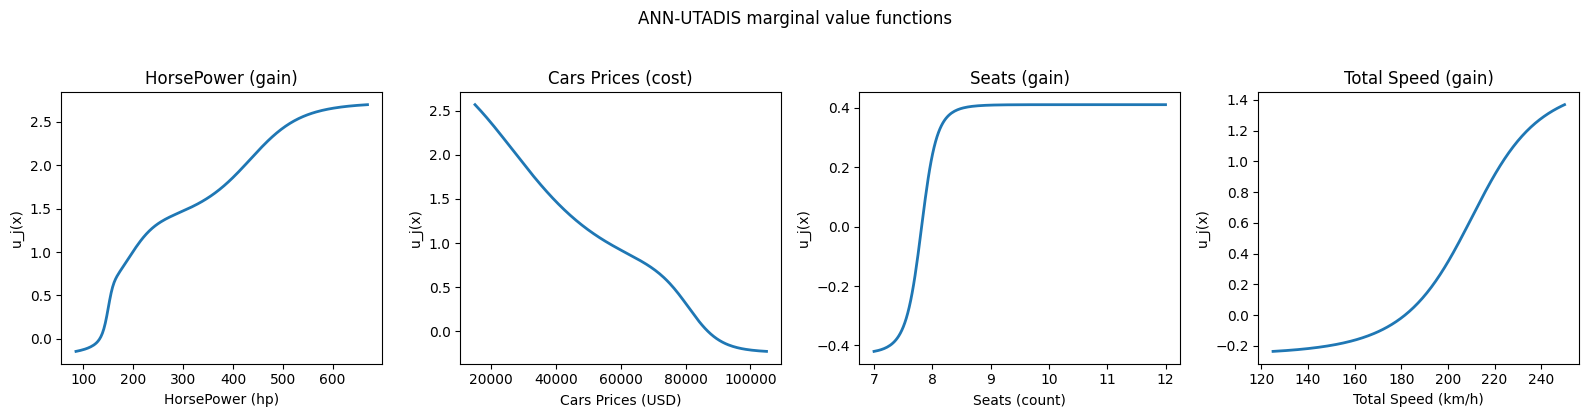

Marginal value ranges (learned criterion 'weights'):
  HorsePower      range = 2.8412
  Cars Prices     range = 2.7985
  Total Speed     range = 1.6051
  Seats           range = 0.8311

Learned threshold τ = 2.4612, scale s = 0.0066


/tmp/ipykernel_403279/3835943683.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"\nLearned threshold τ = {float(model.tau):.4f}, scale s = {float(torch.exp(model.log_s)):.4f}")


In [7]:
def marginal_curve(j: int, f: str):
    lo, hi = FEATURE_RANGES[f]
    xs = np.linspace(lo, hi, 200)
    xs_n = (xs - lo) / (hi - lo)
    if CRITERION_DIRECTION[f] == -1:
        xs_n = 1.0 - xs_n
    with torch.no_grad():
        us = model.marginals[j](torch.tensor(xs_n, dtype=torch.float32).unsqueeze(1)).numpy().ravel()
    return xs, us


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
marginal_ranges = {}
for j, f in enumerate(FEATURE_NAMES):
    xs, us = marginal_curve(j, f)
    axes[j].plot(xs, us, lw=2)
    axes[j].set_title(f"{f} ({'gain' if CRITERION_DIRECTION[f] == 1 else 'cost'})")
    axes[j].set_xlabel(f"{f} ({CRITERION_UNIT[f]})")
    axes[j].set_ylabel("u_j(x)")
    marginal_ranges[f] = float(us.max() - us.min())

plt.suptitle("ANN-UTADIS marginal value functions", y=1.03)
plt.tight_layout()
plt.show()

print("Marginal value ranges (learned criterion 'weights'):")
for f, r in sorted(marginal_ranges.items(), key=lambda kv: -kv[1]):
    print(f"  {f:14s}  range = {r:.4f}")

print(f"\nLearned threshold τ = {float(model.tau):.4f}, scale s = {float(torch.exp(model.log_s)):.4f}")

## 7. Permutation Feature Importance

Permutation importance (AUC drop):
  HorsePower      +0.3818 ± 0.0347
  Total Speed     +0.2539 ± 0.0366
  Cars Prices     +0.2134 ± 0.0225
  Seats           +0.1257 ± 0.0225


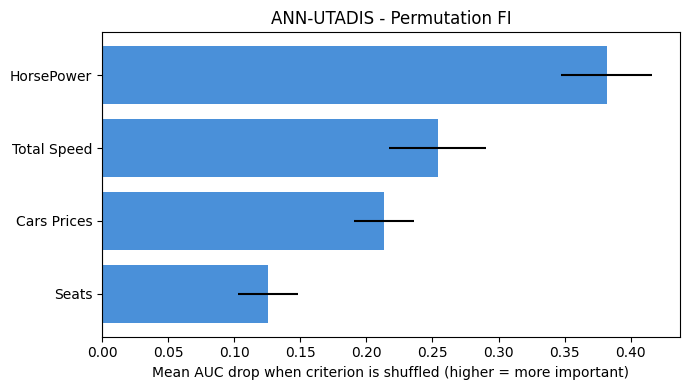

In [8]:
pfi = permutation_feature_importance(predict_proba_df, X_train, y_train,
                                     feature_names=FEATURE_NAMES, n_repeats=30)
print("Permutation importance (AUC drop):")
for f, (m, s) in sorted(pfi.items(), key=lambda kv: -kv[1][0]):
    print(f"  {f:14s}  {m:+.4f} ± {s:.4f}")
plot_permutation_importance(pfi, title="ANN-UTADIS - Permutation FI")

## 8. PDP and ICE

Because the model is **additive**, the PDP for each criterion is (up to a
constant shift and the sigmoid link) just the marginal value function.  ICE
curves should all have the same *shape* as the PDP - any spread visible in
ICE comes from different baseline utilities shifting the sigmoid, not from
interactions, which the architecture makes impossible.

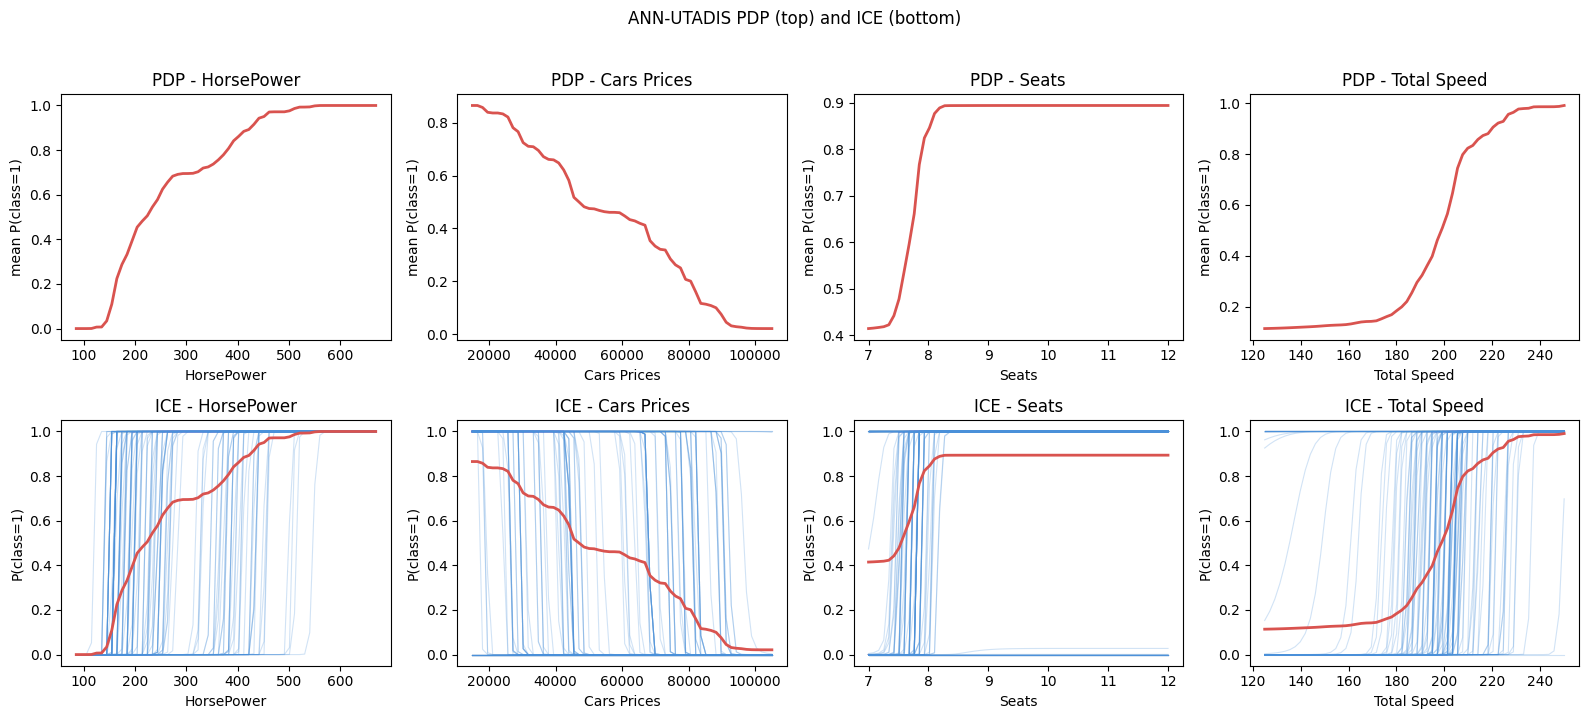

In [9]:
plot_pdp_ice_grid(predict_proba_df, X_train, FEATURE_NAMES, FEATURE_RANGES,
                  title_prefix="ANN-UTADIS PDP (top) and ICE (bottom)")

## 9. Select 3 alternatives for deep explanation

In [10]:
df_pred = df.copy()
df_pred['pred']      = predict_df(X)
df_pred['pred_prob'] = predict_proba_df(X)

selected = select_three_alternatives(df_pred)

print("Selected alternatives:")
for idx, lbl in selected:
    row = df_pred.loc[idx]
    print(f"  [{lbl}] {get_name(df_raw, idx)}")
    print(f"    HP={row['HorsePower']:.0f} hp, Price=${row['Cars Prices']:.0f}, "
          f"Seats={row['Seats']:.0f}, Speed={row['Total Speed']:.0f} km/h")
    print(f"    Utility={row['utility']:.4f}  Pred prob={row['pred_prob']:.4f}  Class={int(row['pred'])}")

Selected alternatives:
  [Preferred] TOYOTA TOYOTA SEQUOIA
    HP=381 hp, Price=$50000, Seats=7, Speed=200 km/h
    Utility=1.7171  Pred prob=1.0000  Class=1
  [Borderline] Mitsubishi Outlander SE
    HP=181 hp, Price=$30500, Seats=7, Speed=190 km/h
    Utility=1.5119  Pred prob=0.0048  Class=0
  [Not preferred] TOYOTA FORTUNER GR SPORT
    HP=204 hp, Price=$55000, Seats=7, Speed=175 km/h
    Utility=1.1590  Pred prob=0.0000  Class=0


## 10. SHAP explanations

For an additive UTADIS model, SHAP values have a closed form:
`SHAP_j(x) = u_j(x_j) − E_background[u_j(X_j)]`.  We compute them both
analytically (fast and exact for this model class) and via KernelExplainer
as a sanity check - the two should agree up to numerical noise.

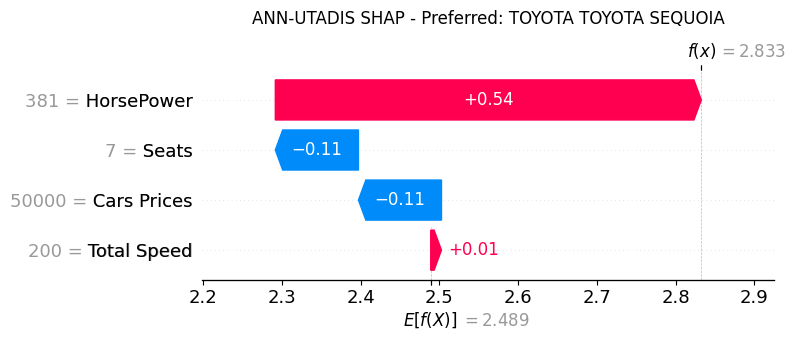

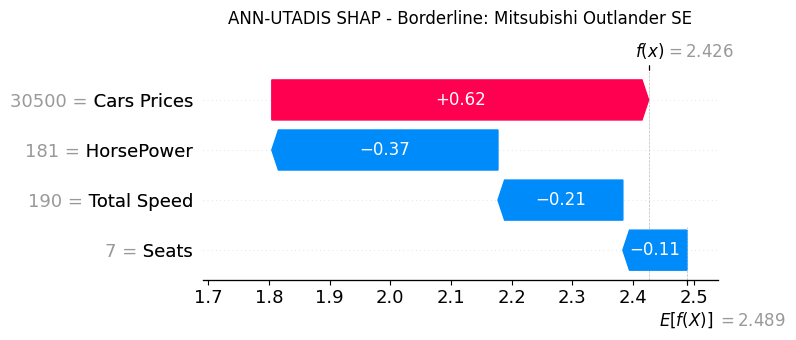

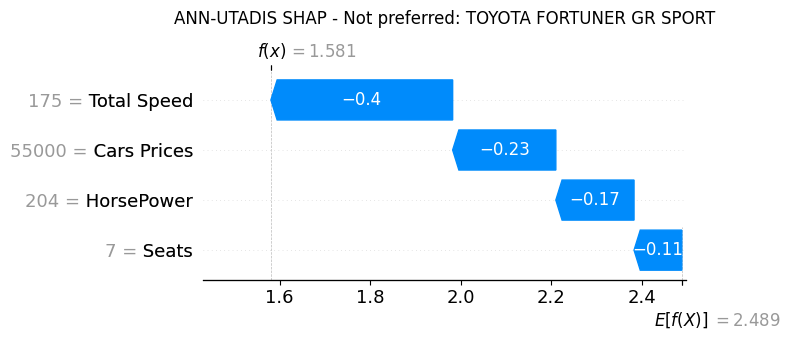

/tmp/ipykernel_403279/255543134.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_all, X, feature_names=FEATURE_NAMES, show=False)


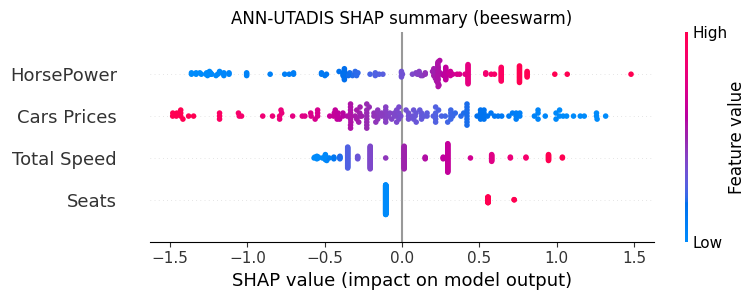

In [11]:
with torch.no_grad():
    U_train = model.utilities(torch.tensor(X_train_n, dtype=torch.float32)).numpy()
baseline = U_train.mean(axis=0)

def analytic_shap(X_df: pd.DataFrame) -> np.ndarray:
    Xn = preprocess(X_df)
    with torch.no_grad():
        U = model.utilities(torch.tensor(Xn, dtype=torch.float32)).numpy()
    return U - baseline


shap_values_all = analytic_shap(X)
base_value = float(baseline.sum())

for idx, lbl in selected:
    row = X.loc[[idx]]
    name = get_name(df_raw, idx)
    sv = analytic_shap(row)[0]
    explanation = shap.Explanation(
        values        = sv,
        base_values   = base_value,
        data          = row.values[0],
        feature_names = FEATURE_NAMES,
    )
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"ANN-UTADIS SHAP - {lbl}: {name}", pad=12)
    plt.tight_layout()
    plt.show()

shap.summary_plot(shap_values_all, X, feature_names=FEATURE_NAMES, show=False)
plt.title("ANN-UTADIS SHAP summary (beeswarm)")
plt.tight_layout()
plt.show()

## 11. Minimum single-criterion change to flip class (analytical)

Because every marginal `u_j` is monotone, a flip exists on criterion `j` iff
the opposite side of the threshold τ is reachable by moving that single
criterion across its full range (keeping all others fixed).  We compute the
required `u_j*` from `τ = U_others + u_j*`, then invert `u_j` numerically on
a fine 1-D grid.  This is exact (no free parameters, no sampling noise) and
uses only the learned model parameters.

In [12]:
def invert_marginal(j: int, target_u: float, f: str):
    """Return the *raw* criterion value whose marginal equals target_u (closest)."""
    xs, us = marginal_curve(j, f)
    i = int(np.argmin(np.abs(us - target_u)))
    return float(xs[i]), float(us[i])


def analytical_flip(idx):
    row = df_pred.loc[idx]
    x_raw = row[FEATURE_NAMES].values.astype(float)
    x_n = preprocess(pd.DataFrame([x_raw], columns=FEATURE_NAMES))
    with torch.no_grad():
        u_parts = model.utilities(torch.tensor(x_n, dtype=torch.float32)).numpy()[0]
        U = float(u_parts.sum())
    tau = float(model.tau)
    current_pred = int(U > tau)
    results = []
    for j, f in enumerate(FEATURE_NAMES):
        U_others = U - u_parts[j]
        u_needed = tau - U_others
        xs, us = marginal_curve(j, f)
        # candidates that actually cross the threshold (sign change in us - u_needed)
        diffs = us - u_needed
        if current_pred == 1:
            mask = diffs < 0          # need u_j smaller than u_needed -> class 0
        else:
            mask = diffs > 0
        if not mask.any():
            continue
        candidates = xs[mask]
        # smallest |delta| from current raw value
        orig = x_raw[j]
        i = int(np.argmin(np.abs(candidates - orig)))
        new_val = float(candidates[i])
        results.append({
            'criterion': f,
            'orig_value': float(orig),
            'new_value': new_val,
            'delta': new_val - float(orig),
            'u_needed': float(u_needed),
            'old_pred': current_pred,
        })
    return current_pred, results


print("=" * 60)
analytical_results = {}
for idx, lbl in selected:
    row = df_pred.loc[idx]
    name = get_name(df_raw, idx)
    current_pred, flips = analytical_flip(idx)
    print(f"\n[{lbl}] {name}  (class = {current_pred})")
    if not flips:
        print("  -> No single-criterion change can flip the class")
    for f in flips:
        print(f"  -> '{f['criterion']}' : {f['orig_value']:.1f} -> {f['new_value']:.1f}  "
              f"(Δ = {f['delta']:+.1f})   [needs u_j = {f['u_needed']:.4f}]")
    analytical_results[idx] = flips


[Preferred] TOYOTA TOYOTA SEQUOIA  (class = 1)
  -> 'HorsePower' : 381.0 -> 267.3  (Δ = -113.7)   [needs u_j = 1.3869]
  -> 'Cars Prices' : 50000.0 -> 67462.3  (Δ = +17462.3)   [needs u_j = 0.7770]
  -> 'Total Speed' : 200.0 -> 179.0  (Δ = -21.0)   [needs u_j = -0.0254]

[Borderline] Mitsubishi Outlander SE  (class = 0)
  -> 'HorsePower' : 181.0 -> 187.9  (Δ = +6.9)   [needs u_j = 0.8800]
  -> 'Cars Prices' : 30500.0 -> 29472.4  (Δ = -1027.6)   [needs u_j = 1.9101]
  -> 'Seats' : 7.0 -> 7.4  (Δ = +0.4)   [needs u_j = -0.3846]
  -> 'Total Speed' : 190.0 -> 192.2  (Δ = +2.2)   [needs u_j = 0.1618]

[Not preferred] TOYOTA FORTUNER GR SPORT  (class = 0)
  -> 'HorsePower' : 204.0 -> 414.2  (Δ = +210.2)   [needs u_j = 1.9249]
  -> 'Cars Prices' : 55000.0 -> 29472.4  (Δ = -25527.6)   [needs u_j = 1.9060]
  -> 'Total Speed' : 175.0 -> 216.7  (Δ = +41.7)   [needs u_j = 0.8110]


## 12. Sampling verification

We apply the analytical minimum change to the selected alternatives and
check that the model really does flip.  We also run the model-agnostic
grid search (`find_min_flip_sampling`) to double-check.

In [13]:
print("=" * 60)
for idx, lbl in selected:
    name = get_name(df_raw, idx)
    row = df_pred.loc[idx]
    flips = analytical_results.get(idx, [])
    print(f"\n[{lbl}] {name}  (original class = {int(row['pred'])})")

    if not flips:
        print("  No analytical flip.")
    else:
        best = min(flips, key=lambda r: abs(r['delta']))
        test_row = row[FEATURE_NAMES].copy()
        test_row[best['criterion']] = best['new_value']
        sampled_pred  = int(predict_df(pd.DataFrame([test_row]))[0])
        sampled_prob  = float(predict_proba_df(pd.DataFrame([test_row]))[0])
        agree = "✓ AGREE" if sampled_pred != best['old_pred'] else "✗ DISAGREE"
        print(f"  Analytical: '{best['criterion']}' -> {best['new_value']:.1f}  (Δ={best['delta']:+.1f})")
        print(f"  Sampling:   class={sampled_pred}  prob={sampled_prob:.4f}   {agree}")

    # Independent grid search (model-agnostic)
    grid_flips = find_min_flip_sampling(predict_df, row, FEATURE_NAMES, FEATURE_RANGES)
    if grid_flips:
        best_grid = min(grid_flips, key=lambda r: abs(r['delta']))
        print(f"  Grid  :    '{best_grid['criterion']}' Δ={best_grid['delta']:+.1f} -> class {best_grid['new_pred']}")


[Preferred] TOYOTA TOYOTA SEQUOIA  (original class = 1)
  Analytical: 'Total Speed' -> 179.0  (Δ=-21.0)
  Sampling:   class=0  prob=0.3387   ✓ AGREE
  Grid  :    'Total Speed' Δ=-20.8 -> class 0

[Borderline] Mitsubishi Outlander SE  (original class = 0)
  Analytical: 'Seats' -> 7.4  (Δ=+0.4)
  Sampling:   class=1  prob=0.6365   ✓ AGREE
  Grid  :    'Seats' Δ=+0.4 -> class 1

[Not preferred] TOYOTA FORTUNER GR SPORT  (original class = 0)
  Analytical: 'Total Speed' -> 216.7  (Δ=+41.7)
  Sampling:   class=1  prob=0.8542   ✓ AGREE
  Grid  :    'Total Speed' Δ=+41.5 -> class 1


## 13. Model interpretation summary

* **User preferences**: read directly from the marginal value functions.
  The criterion with the *largest range* of `u_j` is the most decisive.
  Criteria whose `u_j` is nearly flat do not influence the decision.

* **Criterion nature**: all four criteria are monotone by construction
  (HP, Seats, Total Speed as gain; Cars Prices as cost).  Because the
  network cannot represent a non-monotone response, the user is assumed
  to prefer more of a gain criterion and less of a cost criterion.

* **Preference thresholds**: the sigmoid link is centred on `τ` - any point
  with total utility `U(x) > τ` is class 1, else class 0.  Flat regions on
  the left/right of each marginal correspond to ranges of the criterion
  that are **preference-indifferent** for the user.

* **Criterion dependencies**: the additive form `U = Σ u_j` means the model
  *cannot* represent interactions between criteria.  This is a design
  choice; PFI gives a sanity check.  If the model still scores well, the
  user's preferences are well-approximated by an additive structure.

* **Weights**: the range of each `u_j` plays the role of a UTADIS criterion
  weight.  Reading them off directly is the textbook UTADIS interpretation.